In [24]:
import uproot
import awkward as ak
import matplotlib.pyplot as plt
import numpy as np

In [25]:
# Names from json file:
names_json = ["SM","cQu8","ctu8","cQu1","ctd8","cQlMi","cpQ3","ctlTi","ctG","ctZ","ctW","ctli","ctb8","cbW","cQl3i","cQq13",
              "cptb","ctp","ctei","cpQM","ctlSi", "cQq83","cQq81","ctq1","ctu1","cQei","cQb8","cpt","ctq8","cQd1","cQq11",
              "cQd8","ctd1"]

# All 561 combinations of coefficients (i.e SM,SM; SM,cQu8; cQu8,cQu8; SM,ctu8; cQu8,ctu8; ...)
name_combinations = []
for i in range(len(names_json)):
    for a in range(i+1):
        name_combinations.append([names_json[i],names_json[a]])

In [26]:
# Open file
file = uproot.open("sample_root_files/output_570.root")
# Open Events tree
events_tree = file['Events']
# Making array of EFT Coefficients
eft_coeff = events_tree['EFTfitCoefficients'].array()

In [27]:
# Getting the mean and median of the coefficient values
mean = []
median = []

for i in range(561):
    mean.append(np.mean(np.abs(eft_coeff[:,i])))
    median.append(np.median(np.abs(eft_coeff[:,i])))

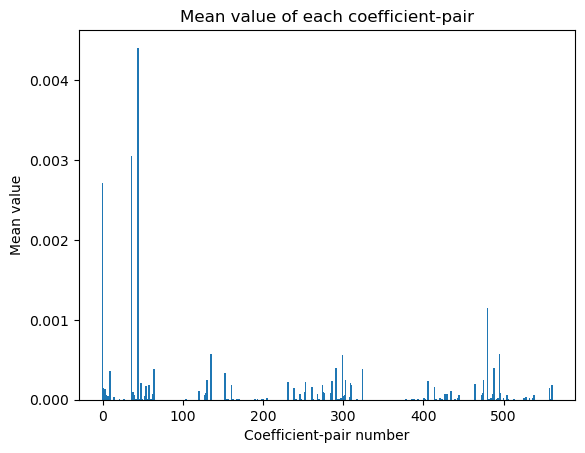

The following indices have a value higher than 0.0005

 Index: 44.0 (['ctG', 'ctG']) has mean 0.0044054

 Index: 36.0 (['ctG', 'SM']) has mean 0.0030494

 Index: 0.0 (['SM', 'SM']) has mean 0.0027099

 Index: 480.0 (['cQq11', 'cQq13']) has mean 0.0011471

 Index: 135.0 (['cQq13', 'cQq13']) has mean 0.0005742

 Index: 495.0 (['cQq11', 'cQq11']) has mean 0.000574

 Index: 299.0 (['ctq1', 'ctq1']) has mean 0.0005537


In [78]:
# Plotting the mean and median of the coefficient values
coeffs = np.arange(0,561)

plt.bar(coeffs,mean, width = 2)
plt.xlabel('Coefficient-pair number')
plt.ylabel('Mean value')
plt.title('Mean value of each coefficient-pair')
#plt.yscale('log')
plt.show()

index_and_mean = []
for i,n in enumerate(mean):
    if abs(n) > 0.0005:
        index_and_mean.append([i, abs(n)])
        
index_and_mean = np.array(index_and_mean)
order = np.argsort(index_and_mean[:,1])
index_and_mean_ordered = index_and_mean[order][::-1]

print('The following indices have a value higher than 0.0005')

for i in range(len(index_and_mean_ordered)):
    print(f'\n Index: {index_and_mean_ordered[i,0]} ({name_combinations[int(index_and_mean_ordered[i,0])]}) has mean {np.round(index_and_mean_ordered[i,1], decimals = 7)}')

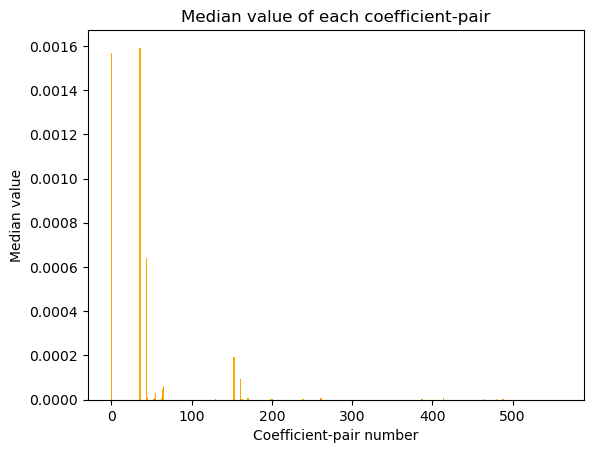

The following indices have a value higher than 0.0001

 Index: 36.0 (['ctG', 'SM']) has median 0.001591

 Index: 0.0 (['SM', 'SM']) has median 0.001568

 Index: 44.0 (['ctG', 'ctG']) has median 0.000641

 Index: 153.0 (['ctp', 'SM']) has median 0.000195


In [71]:
plt.bar(coeffs,median, color='orange',width = 2)
plt.xlabel('Coefficient-pair number')
plt.ylabel('Median value')
plt.title('Median value of each coefficient-pair')
#plt.yscale('log')
plt.show()

index_and_median = []
for i,n in enumerate(median):
    if abs(n) > 0.0001:
        index_and_median.append([i, abs(n)])
        
index_and_median = np.array(index_and_median)
order = np.argsort(index_and_median[:,1])
index_and_median_ordered = index_and_median[order][::-1]

print('The following indices have a value higher than 0.0001')

for i in range(len(index_and_median_ordered)):
    print(f'\n Index: {index_and_median_ordered[i,0]} ({name_combinations[int(index_and_median_ordered[i,0])]}) has median {np.round(index_and_median_ordered[i,1], decimals = 6)}')

The following indices have a value higher than 0.0001

 Index: 36.0 (['ctG', 'SM']) has median 0.001591

 Index: 0.0 (['SM', 'SM']) has median 0.001568

 Index: 44.0 (['ctG', 'ctG']) has median 0.000641

 Index: 153.0 (['ctp', 'SM']) has median 0.000195


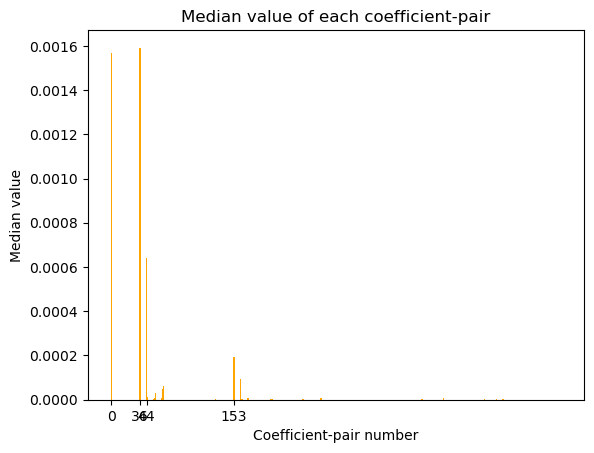

In [76]:
index_and_median = []
for i,n in enumerate(median):
    if abs(n) > 0.0001:
        index_and_median.append([i, abs(n)])
        
index_and_median = np.array(index_and_median)
order = np.argsort(index_and_median[:,1])
index_and_median_ordered = index_and_median[order][::-1]

print('The following indices have a value higher than 0.0001')

for i in range(len(index_and_median_ordered)):
    print(f'\n Index: {index_and_median_ordered[i,0]} ({name_combinations[int(index_and_median_ordered[i,0])]}) has median {np.round(index_and_median_ordered[i,1], decimals = 6)}')
plt.bar(coeffs,median, color='orange',width = 2)
plt.xlabel('Coefficient-pair number')
plt.ylabel('Median value')
plt.title('Median value of each coefficient-pair')
plt.xticks(index_and_median[:,0])
#plt.yscale('log')
plt.show()

In [72]:
# IMPORTANT NOTE FOR THE MEAN: The highest mean corresponds to coefficient #44. If you take a look at the values in each event for
# this pair, you will see it has pretty big numbers compared to other lists! For example, the largest value is 18.9, where coefficient #0
# has a max of 0.1. Compare the lists with the code right below.

eft_coeff_44_sorted = np.sort(np.abs(eft_coeff[:,44]))[::-1] # Sorted from max to min
eft_coeff_44_sorted[0] # Printing the first_value

np.float32(18.86914)

In [73]:
# Pick whatever coeff index you want to sort from max to min:
coeff_of_interest = 0
eft_coeff_of_interest_sorted = np.sort(np.abs(eft_coeff[:,coeff_of_interest]))[::-1] # Sorted from max to min
eft_coeff_of_interest_sorted[0] # Printing the first value (max value)

np.float32(0.1004982)